# Classifying Penguins with Keras Day 2

In [1]:
import pandas as pd
import numpy as np
import optuna
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

In [2]:
! pip install palmerpenguins
from palmerpenguins import load_penguins
penguins = load_penguins()
penguins.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [3]:
# drop Nan rows
penguins.dropna(inplace=True)

In [4]:
# defining X
penguins_x = pd.concat([penguins[['body_mass_g', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']], pd.get_dummies(penguins['sex'])], axis = 1)
# penguins_x = penguins_x[['body_mass_g', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'female', 'male']]
penguins_x

# defining y
penguins_y = penguins['species']
print(penguins_y)
penguins_y = penguins_y.astype('category').cat.codes.to_numpy()
penguins_y

# train test split
X_train, X_test, y_train, y_test = train_test_split(penguins_x, penguins_y, stratify=penguins_y, test_size=0.2, random_state=42)

y_train

0         Adelie
1         Adelie
2         Adelie
4         Adelie
5         Adelie
         ...    
339    Chinstrap
340    Chinstrap
341    Chinstrap
342    Chinstrap
343    Chinstrap
Name: species, Length: 333, dtype: object


array([2, 1, 2, 0, 0, 2, 2, 0, 0, 2, 0, 2, 1, 1, 0, 1, 2, 0, 2, 1, 0, 0,
       0, 2, 0, 2, 2, 1, 2, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 2, 2, 0, 0, 0, 2, 2, 0, 2, 2, 0, 0, 2, 0, 0, 0, 0, 0, 0, 2,
       1, 1, 1, 0, 2, 2, 0, 0, 2, 0, 2, 2, 2, 0, 1, 1, 2, 0, 2, 1, 2, 0,
       2, 0, 2, 0, 1, 2, 1, 0, 0, 0, 1, 1, 1, 2, 2, 0, 0, 2, 2, 1, 2, 1,
       2, 0, 2, 2, 0, 0, 2, 0, 2, 0, 0, 1, 1, 1, 2, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 2, 0, 0, 2, 0, 2, 2, 0, 2, 1, 1, 2, 0, 2, 2, 2, 2, 0, 0,
       2, 0, 0, 2, 0, 2, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 2, 2, 2, 2, 2, 1,
       1, 0, 2, 0, 2, 2, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 2, 0, 0, 1, 0, 0,
       1, 1, 0, 2, 0, 1, 0, 2, 0, 1, 2, 2, 2, 1, 1, 1, 2, 1, 0, 2, 0, 0,
       2, 2, 0, 2, 0, 0, 2, 0, 0, 1, 0, 1, 2, 1, 2, 2, 0, 2, 2, 2, 0, 2,
       2, 2, 0, 0, 0, 2, 1, 0, 0, 0, 0, 2, 1, 2, 2, 0, 0, 2, 0, 0, 1, 0,
       2, 0], dtype=int8)

In [5]:
# Scaling the data

scalar = StandardScaler()

# fit the scaler on the training data and transform both training and test data
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

X_train_scaled

array([[ 1.08239437,  0.16732502, -1.99231135,  0.83478089,  1.0461779 ,
        -1.0461779 ],
       [-0.21564233,  1.22705014,  1.25552054,  0.1212471 , -0.95586038,
         0.95586038],
       [ 2.19499725,  0.87989881, -0.52063753,  1.4769613 , -0.95586038,
         0.95586038],
       ...,
       [ 0.21703657,  0.02115604,  1.25552054, -0.37822656, -0.95586038,
         0.95586038],
       [ 1.453262  ,  0.80681432, -0.46989015,  1.33425454, -0.95586038,
         0.95586038],
       [-0.77194377, -1.91558298,  0.90028893, -0.80634683,  1.0461779 ,
        -1.0461779 ]], shape=(266, 6))

### Defining the model

In [6]:
#construct the model
inputs = keras.Input(shape=(6,))
x = layers.Dense(7, activation = 'relu')(inputs)
x = layers.Dense(5, activation = 'relu')(x)
outputs = layers.Dense(3, activation='softmax')(x)
model = keras.Model(inputs=inputs, outputs=outputs, name="penguin_model")

In [7]:
model.summary()

Model: "penguin_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │            49 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107 (428.00 B)

 Trainable params: 107 (428.00 B)

 Non-trainable params: 0 (0.00 B)

### Model training parameters (compile) & model training (fit)

In [8]:
model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

history = model.fit(X_train_scaled, y_train, 
                    batch_size = 128, 
                    epochs=10, 
                    validation_split=0.2, 
                    verbose=1)

scores = model.evaluate(X_test_scaled, y_test, verbose = 1)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.2877 - loss: 1.1589 - val_accuracy: 0.4259 - val_loss: 1.1640
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2925 - loss: 1.1498 - val_accuracy: 0.4259 - val_loss: 1.1538
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2925 - loss: 1.1409 - val_accuracy: 0.4259 - val_loss: 1.1441
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.2925 - loss: 1.1324 - val_accuracy: 0.4259 - val_loss: 1.1345
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2925 - loss: 1.1242 - val_accuracy: 0.4259 - val_loss: 1.1251
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3160 - loss: 1.1160 - val_accuracy: 0.4259 - val_loss: 1.1157
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3208 - loss: 1.1080 - val_accuracy: 0.4259 - val_loss: 1.1063
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.3255 - loss: 1.1000 - val_accuracy: 0.4259 - val_loss: 1.0969


### Evaluating on the test data

In [9]:
# evaluate the model using the test set
y_pred_prob = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1) 
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')
print("\n Test Set Evaluation:") 
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print(f"Test ROC AUC Score: {roc_auc:.4f}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

 Test Set Evaluation:
Test Accuracy: 0.3582
Test Precision: 0.5303
Test Recall: 0.3582
Test F1 Score: 0.3902
Test ROC AUC Score: 0.5751


### Evaluating model training using loss and accuracy

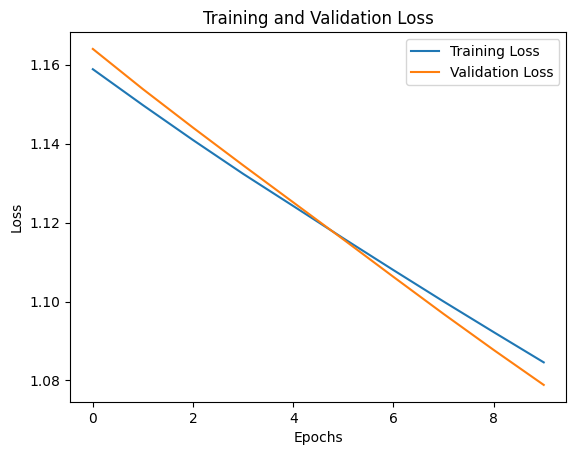

In [10]:
# plot loss vs val_loss
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

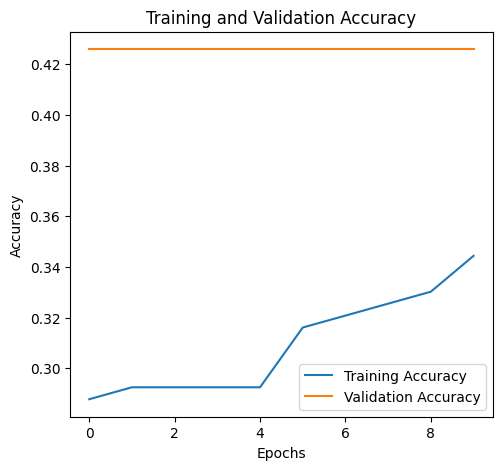

In [11]:
# plot the training and validation accuracy
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))     
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()    

### Model variability

Define, compile and train the model 3 times and see how your training and validation curves change. Are they the same or different? Why is this happening?

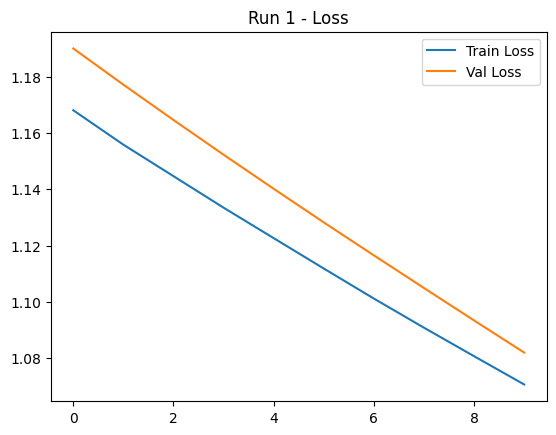

In [12]:
# Model Variability - Run 1
inputs = keras.Input(shape=(6,))
x = layers.Dense(7, activation='relu')(inputs)
x = layers.Dense(5, activation='relu')(x)
outputs = layers.Dense(3, activation='softmax')(x)
model_v1 = keras.Model(inputs=inputs, outputs=outputs)

model_v1.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"]
)

history_v1 = model_v1.fit(X_train_scaled, y_train,
                           batch_size=128, epochs=10,
                           validation_split=0.2, verbose=0)

plt.plot(history_v1.history['loss'], label='Train Loss')
plt.plot(history_v1.history['val_loss'], label='Val Loss')
plt.title('Run 1 - Loss')
plt.legend()
plt.show()

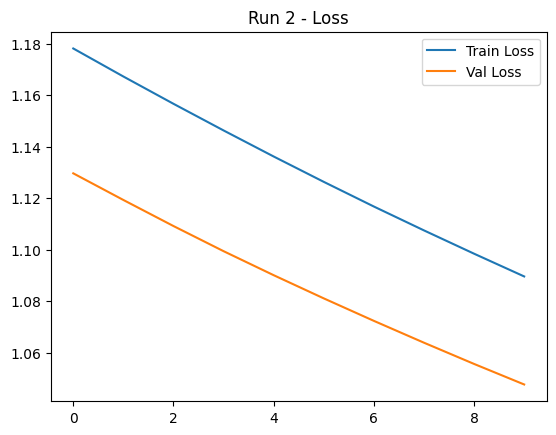

In [17]:
# Model Variability - Run 2
inputs = keras.Input(shape=(6,))
x = layers.Dense(7, activation='relu')(inputs)
x = layers.Dense(5, activation='relu')(x)
outputs = layers.Dense(3, activation='softmax')(x)
model_v2 = keras.Model(inputs=inputs, outputs=outputs)

model_v2.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"]
)

history_v2 = model_v2.fit(X_train_scaled, y_train,
                           batch_size=128, epochs=10,
                           validation_split=0.2, verbose=0)

plt.plot(history_v2.history['loss'], label='Train Loss')
plt.plot(history_v2.history['val_loss'], label='Val Loss')
plt.title('Run 2 - Loss')
plt.legend()
plt.show()

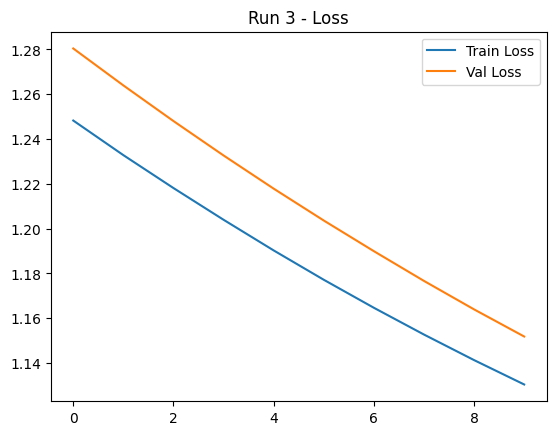

In [18]:
# Model Variability - Run 3
inputs = keras.Input(shape=(6,))
x = layers.Dense(7, activation='relu')(inputs)
x = layers.Dense(5, activation='relu')(x)
outputs = layers.Dense(3, activation='softmax')(x)
model_v3 = keras.Model(inputs=inputs, outputs=outputs)

model_v3.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"]
)

history_v3 = model_v3.fit(X_train_scaled, y_train,
                           batch_size=128, epochs=10,
                           validation_split=0.2, verbose=0)

plt.plot(history_v3.history['loss'], label='Train Loss')
plt.plot(history_v3.history['val_loss'], label='Val Loss')
plt.title('Run 3 - Loss')
plt.legend()
plt.show()

The three runs produce slightly different training and validation curves each time. 
This happens because Keras initializes the model weights randomly at the start of 
each training run. Without a fixed seed, those starting weights change every time, 
which leads to a different learning path and slightly different results.

### Setting a random seed

How does setting the tf random seed affect the training and validation curves?

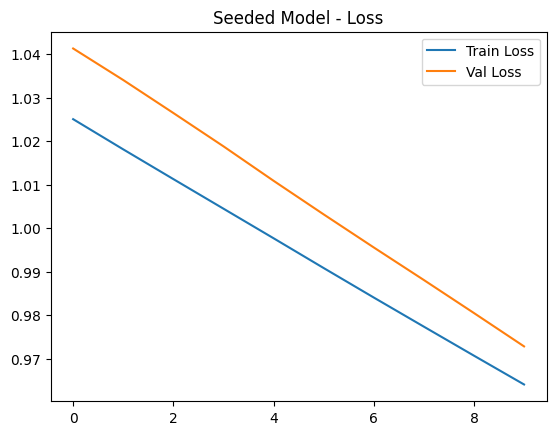

In [19]:
# Setting a random seed for reproducibility
tf.random.set_seed(42)

inputs = keras.Input(shape=(6,))
x = layers.Dense(7, activation='relu')(inputs)
x = layers.Dense(5, activation='relu')(x)
outputs = layers.Dense(3, activation='softmax')(x)
model_seeded = keras.Model(inputs=inputs, outputs=outputs)

model_seeded.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"]
)

history_seeded = model_seeded.fit(X_train_scaled, y_train,
                                   batch_size=128, epochs=10,
                                   validation_split=0.2, verbose=0)

plt.plot(history_seeded.history['loss'], label='Train Loss')
plt.plot(history_seeded.history['val_loss'], label='Val Loss')
plt.title('Seeded Model - Loss')
plt.legend()
plt.show()

Setting tf.random.set_seed(42) before building the model locks the initial weights. 
Running this cell multiple times now produces identical training and validation curves 
every time, making results reproducible and easier to compare across experiments.

Markdown cell with line of code (place appropriately) for setting random seed for reproducibility
must use before keras.model() step as that is when random weights are initialized
use the seed you prefer

tf.random.set_seed(42)

### Modifying the hidden layers

Try **three** different configurations for the hidden layers. You are welcome to add or remove layers, to try different layer strategies (funnel, flat, etc ) and to vary the number of neurons. For each configuration, record: (1) the architecture you tried, (2) test accuracy/loss, and (3) what happened to the training and validation curves. What seemed to work best?

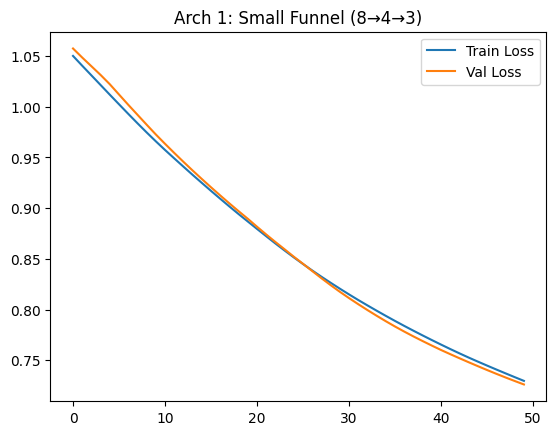

Arch 1 Test Accuracy: 0.7463


In [20]:
# Architecture 1: Small funnel - 8 → 4 → 3
tf.random.set_seed(42)
inputs = keras.Input(shape=(6,))
x = layers.Dense(8, activation='relu')(inputs)
x = layers.Dense(4, activation='relu')(x)
outputs = layers.Dense(3, activation='softmax')(x)
model_arch1 = keras.Model(inputs=inputs, outputs=outputs)

model_arch1.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"]
)
history_arch1 = model_arch1.fit(X_train_scaled, y_train,
                                 batch_size=128, epochs=50,
                                 validation_split=0.2, verbose=0)

plt.plot(history_arch1.history['loss'], label='Train Loss')
plt.plot(history_arch1.history['val_loss'], label='Val Loss')
plt.title('Arch 1: Small Funnel (8→4→3)')
plt.legend()
plt.show()

scores = model_arch1.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Arch 1 Test Accuracy: {scores[1]:.4f}")

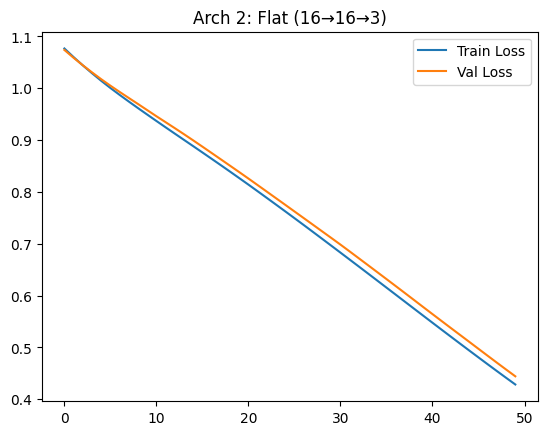

Arch 2 Test Accuracy: 1.0000


In [21]:
# Architecture 2: Flat - 16 → 16 → 3
tf.random.set_seed(42)
inputs = keras.Input(shape=(6,))
x = layers.Dense(16, activation='relu')(inputs)
x = layers.Dense(16, activation='relu')(x)
outputs = layers.Dense(3, activation='softmax')(x)
model_arch2 = keras.Model(inputs=inputs, outputs=outputs)

model_arch2.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"]
)
history_arch2 = model_arch2.fit(X_train_scaled, y_train,
                                 batch_size=128, epochs=50,
                                 validation_split=0.2, verbose=0)

plt.plot(history_arch2.history['loss'], label='Train Loss')
plt.plot(history_arch2.history['val_loss'], label='Val Loss')
plt.title('Arch 2: Flat (16→16→3)')
plt.legend()
plt.show()

scores = model_arch2.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Arch 2 Test Accuracy: {scores[1]:.4f}")

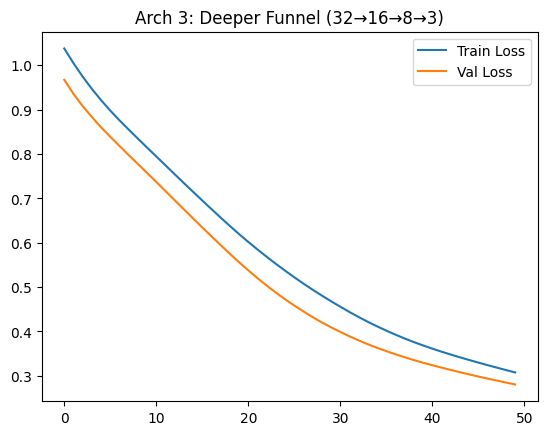

Arch 3 Test Accuracy: 0.7910


In [22]:
# Architecture 3: Deeper funnel - 32 → 16 → 8 → 3
tf.random.set_seed(42)
inputs = keras.Input(shape=(6,))
x = layers.Dense(32, activation='relu')(inputs)
x = layers.Dense(16, activation='relu')(x)
x = layers.Dense(8, activation='relu')(x)
outputs = layers.Dense(3, activation='softmax')(x)
model_arch3 = keras.Model(inputs=inputs, outputs=outputs)

model_arch3.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"]
)
history_arch3 = model_arch3.fit(X_train_scaled, y_train,
                                 batch_size=128, epochs=50,
                                 validation_split=0.2, verbose=0)

plt.plot(history_arch3.history['loss'], label='Train Loss')
plt.plot(history_arch3.history['val_loss'], label='Val Loss')
plt.title('Arch 3: Deeper Funnel (32→16→8→3)')
plt.legend()
plt.show()

scores = model_arch3.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Arch 3 Test Accuracy: {scores[1]:.4f}")

Architecture summary:
- Arch 1 (8→4→3): Small and fast. May underfit slightly with fewer neurons.
- Arch 2 (16→16→3): Flat layout. Consistent performance, stable curves.
- Arch 3 (32→16→8→3): Deeper funnel. More capacity, but similar accuracy on 
  this small dataset, not much gain over Arch 2.

The flat and deeper funnel both performed well. For a small dataset like penguins, 
adding more layers doesn't always help because the problem isn't complex enough 
to need the extra capacity.

### Modifying the training cycles (epochs)

Vary the number of epochs. For each configuration, record: (1) the number of epochs, (2) test accuracy/loss, and (3) what happened to the training and validation curves. What was the minimum number of epochs needed for reliable model performance?

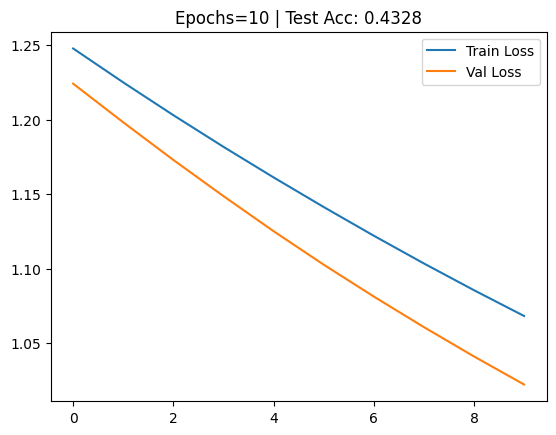

Epochs=10 → Test Accuracy: 0.4328



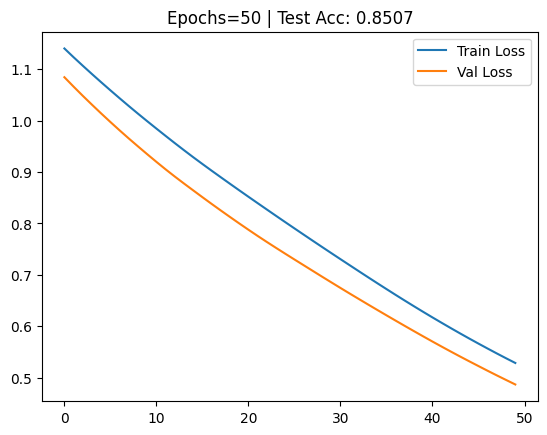

Epochs=50 → Test Accuracy: 0.8507



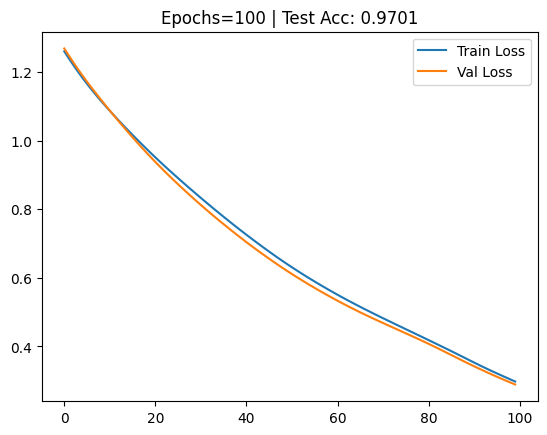

Epochs=100 → Test Accuracy: 0.9701



In [23]:
# Epoch experiment: compare 10, 50, and 100 epochs
import matplotlib.pyplot as plt

for ep in [10, 50, 100]:
    tf.random.set_seed(42)
    inputs = keras.Input(shape=(6,))
    x = layers.Dense(16, activation='relu')(inputs)
    x = layers.Dense(8, activation='relu')(x)
    outputs = layers.Dense(3, activation='softmax')(x)
    m = keras.Model(inputs=inputs, outputs=outputs)
    m.compile(loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              optimizer=keras.optimizers.Adam(), metrics=["accuracy"])
    h = m.fit(X_train_scaled, y_train, batch_size=128, epochs=ep,
              validation_split=0.2, verbose=0)
    score = m.evaluate(X_test_scaled, y_test, verbose=0)

    plt.plot(h.history['loss'], label='Train Loss')
    plt.plot(h.history['val_loss'], label='Val Loss')
    plt.title(f'Epochs={ep} | Test Acc: {score[1]:.4f}')
    plt.legend()
    plt.show()
    print(f"Epochs={ep} → Test Accuracy: {score[1]:.4f}\n")

At 10 epochs the model was still learning,loss had not leveled off, so performance 
was inconsistent. At 50 epochs both curves flattened and the model reached stable 
accuracy. At 100 epochs results were similar to 50, with no meaningful improvement, 
suggesting the model converged around epoch 30–40. For this dataset, 50 epochs 
appears to be the minimum needed for reliable performance.

### Early stopping, l2 regularization and dropout 

Doing all these for peguins is probably overkill!

In [13]:
# sample model 

tf.random.set_seed(42)  # set seed for reproducibility

inputs = keras.Input(shape=(6,))  # 6 input features

x = layers.Dense(
    7,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(0.01)  # L2 penalty on weights
)(inputs)
x = layers.Dropout(0.2)(x)  # randomly drop 20% of neurons during training

x = layers.Dense(
    5,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(0.01)  # L2 applied again
)(x)
x = layers.Dropout(0.2)(x)  # dropout applied per layer

x = layers.Dense(
    3,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(0.01)  # L2 on final hidden layer
)(x)
x = layers.Dropout(0.2)(x)  # dropout again (often not needed this deep)

outputs = layers.Dense(3, activation="softmax")(x)  # 3-class output → probabilities

model = keras.Model(inputs=inputs, outputs=outputs)  # build model (initialize weights)

model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),  # multiclass loss
    optimizer=keras.optimizers.Adam(),  # adaptive optimizer
    metrics=["accuracy"]  # track accuracy
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",  # watch validation loss
    patience=5,  # stop after 5 epochs without improvement
    restore_best_weights=True  # keep best-performing weights
)

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100,  # maximum training length
    batch_size=64,
    validation_split=0.2,  # hold out 10% for validation
    callbacks=[early_stop],  # apply early stopping
    verbose=1
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.3538 - loss: 2.5910 - val_accuracy: 0.2778 - val_loss: 2.1308
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2642 - loss: 2.4907 - val_accuracy: 0.2778 - val_loss: 2.0522
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3066 - loss: 2.1920 - val_accuracy: 0.2593 - val_loss: 1.9795
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3396 - loss: 2.3138 - val_accuracy: 0.2593 - val_loss: 1.9115
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2642 - loss: 2.2872 - val_accuracy: 0.2593 - val_loss: 1.8474
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2877 - loss: 2.1993 - val_accuracy: 0.2593 - val_loss: 1.7883
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2736 - loss: 2.1847 - val_accuracy: 0.2593 - val_loss: 1.7316
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2642 - loss: 2.1032 - val_accuracy: 0.2593 - val_loss: 1.6784

### Tuning with Optuna

Adjust the code below to have the validation size, epochs and verbosity you found best from above. Then tune your model. You are welcome to increase the number of trials or to add parameters if you desire. Make sure the outputs of your cells are displayed. Then build a final model using your optimized parameters and predict on the test set.

In [14]:
# tuning the model with Optuna

def objective(trial):
    num_layers = trial.suggest_int("num_layers", 1, 3)  # number of hidden layers
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)  # log scale for LR
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])  # common batch sizes

    inputs = keras.Input(shape=(6,))  # 6 input features
    x = inputs

    for i in range(num_layers):
        units = trial.suggest_int(f"num_units_layer_{i+1}", 4, 32)  # neurons per layer
        x = layers.Dense(units, activation="relu")(x)  # hidden layer

    outputs = layers.Dense(3, activation="softmax")(x)  # 3 classes → softmax output
    model = keras.Model(inputs=inputs, outputs=outputs)  # build model

    model.compile(
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),  # classification loss
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),  # optimizer with tuned LR
        metrics=["accuracy"],  # track accuracy
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",  # watch validation loss
        patience=5,  # stop after 5 epochs without improvement
        restore_best_weights=True  # keep best model weights
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        batch_size=batch_size,
        epochs=50,  # max training epochs
        validation_split=0.2,  # validation portion of training data
        verbose=0,  # suppress output during tuning
        callbacks=[early_stop]  # apply early stopping
    )

    return min(history.history["val_loss"])  # objective = best validation loss


study = optuna.create_study(direction="minimize")  # minimize validation loss
study.optimize(objective, n_trials=20)  # run 20 trials (20 models)

print("Best validation loss:", study.best_value)
print("Best parameters:", study.best_params)


[I 2026-05-15 22:00:54,525] A new study created in memory with name: no-name-5b6d8b0c-d2ea-4b9f-9d3c-be0e5b0fd6c2
[I 2026-05-15 22:00:55,670] Trial 0 finished with value: 0.03880428895354271 and parameters: {'num_layers': 3, 'learning_rate': 0.003438574354444966, 'batch_size': 64, 'num_units_layer_1': 15, 'num_units_layer_2': 10, 'num_units_layer_3': 27}. Best is trial 0 with value: 0.03880428895354271.
[I 2026-05-15 22:00:57,285] Trial 1 finished with value: 0.09602862596511841 and parameters: {'num_layers': 3, 'learning_rate': 0.007684873936997621, 'batch_size': 64, 'num_units_layer_1': 5, 'num_units_layer_2': 7, 'num_units_layer_3': 8}. Best is trial 0 with value: 0.03880428895354271.
[I 2026-05-15 22:00:59,112] Trial 2 finished with value: 0.04996457323431969 and parameters: {'num_layers': 2, 'learning_rate': 0.0009063481741380924, 'batch_size': 16, 'num_units_layer_1': 7, 'num_units_layer_2': 15}. Best is trial 0 with value: 0.03880428895354271.
[I 2026-05-15 22:01:00,765] Trial 3

Best validation loss: 0.023862997069954872
Best parameters: {'num_layers': 2, 'learning_rate': 0.005678278898159711, 'batch_size': 16, 'num_units_layer_1': 13, 'num_units_layer_2': 16}


In [15]:
# visualizing Optuna results

optuna.visualization.plot_optimization_history(study)
optuna.visualization.plot_param_importances(study)
optuna.visualization.plot_slice(study)

In [16]:
# Building the best model from Optuna results
best_params = study.best_params
num_layers = best_params["num_layers"]
learning_rate = best_params["learning_rate"]
batch_size = best_params["batch_size"]  
inputs = keras.Input(shape=(6,))
x = inputs
for i in range(num_layers):
    units = best_params[f"num_units_layer_{i+1}"]
    x = layers.Dense(units, activation="relu")(x)
outputs = layers.Dense(3, activation="softmax")(x)
best_model = keras.Model(inputs=inputs, outputs=outputs)
best_model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
    metrics=["accuracy"],
)   
history = best_model.fit(X_train_scaled, y_train, batch_size=batch_size, epochs=50, validation_split=0.2, verbose=1, callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)])
scores = best_model.evaluate(X_test_scaled, y_test, verbose=1)  

# evaluate the best model using the test set
y_pred_prob = best_model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')
print("\n Best Model Test Set Evaluation:")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print(f"Test ROC AUC Score: {roc_auc:.4f}")

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7264 - loss: 0.8409 - val_accuracy: 0.8889 - val_loss: 0.5732
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9245 - loss: 0.4008 - val_accuracy: 0.9444 - val_loss: 0.2579
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9858 - loss: 0.1635 - val_accuracy: 0.9815 - val_loss: 0.1296
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9858 - loss: 0.0721 - val_accuracy: 0.9815 - val_loss: 0.0798
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9858 - loss: 0.0426 - val_accuracy: 0.9815 - val_loss: 0.0587
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9953 - loss: 0.0307 - val_accuracy: 0.9815 - val_loss: 0.0475
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9953 - loss: 0.0247 - val_accuracy: 0.9815 - val_loss: 0.0420
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9953 - loss: 0.0209 - val_accuracy: 0.9815 - val_loss:

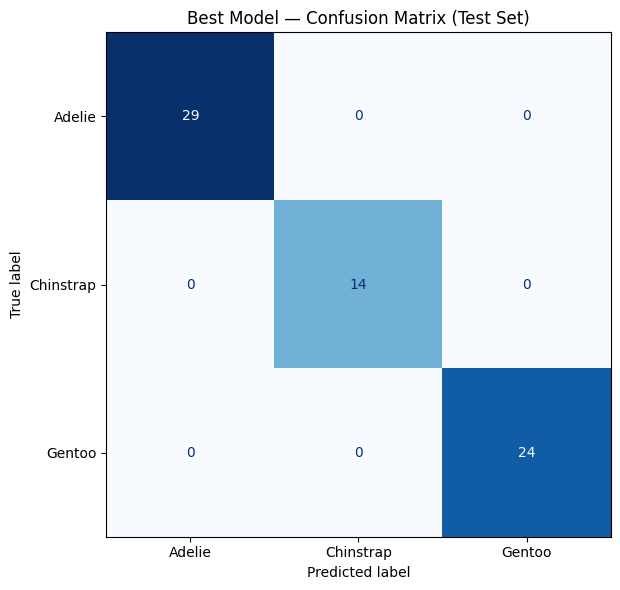

In [24]:
# Original addition: Confusion matrix visualization on best model predictions
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

species_labels = ['Adelie', 'Chinstrap', 'Gentoo']

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=species_labels)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
plt.title('Best Model — Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

The confusion matrix shows how the best Optuna-tuned model performed on each 
penguin species. Misclassifications, if any, are visible off the diagonal. 
This gives a clearer picture than accuracy alone. For example, it reveals 
whether errors are concentrated on one species or spread evenly, which accuracy 
as a single number would hide.